In [7]:
import torch
from src.io.offline import load_raw_data
from src.signal.passivesonar import lofar
from src.signal.utils import resample
from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
import json
import argparse

from src.data_handling import CustomDataloader, LoroCV
from src.visualization import plot_lofargram, plot_tsne_embeddings, palette
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import matplotlib

%load_ext autoreload
%autoreload 2

In [8]:
def load_embeddings_and_targets(results_path):
    """
    Load embeddings and target arrays from .npy files.

    Parameters:
        results_path (Path): Path object to the directory where files are saved.

    Returns:
        embeddings (list of arrays): List of embedding arrays loaded from files.
        all_targets (list of arrays): List of target arrays loaded from files.
    """
    embeddings = []
    all_targets = []
    
    # Get sorted lists of all embedding and target files
    embedding_files = sorted(results_path.glob("embeddings_fold_*.npy"))
    target_files = sorted(results_path.glob("all_targets_fold_*.npy"))

    for emb_file, target_file in zip(embedding_files, target_files):
        embedding = np.load(emb_file)
        target = np.load(target_file)
        embeddings.append(embedding)
        all_targets.append(target)

    return embeddings, all_targets

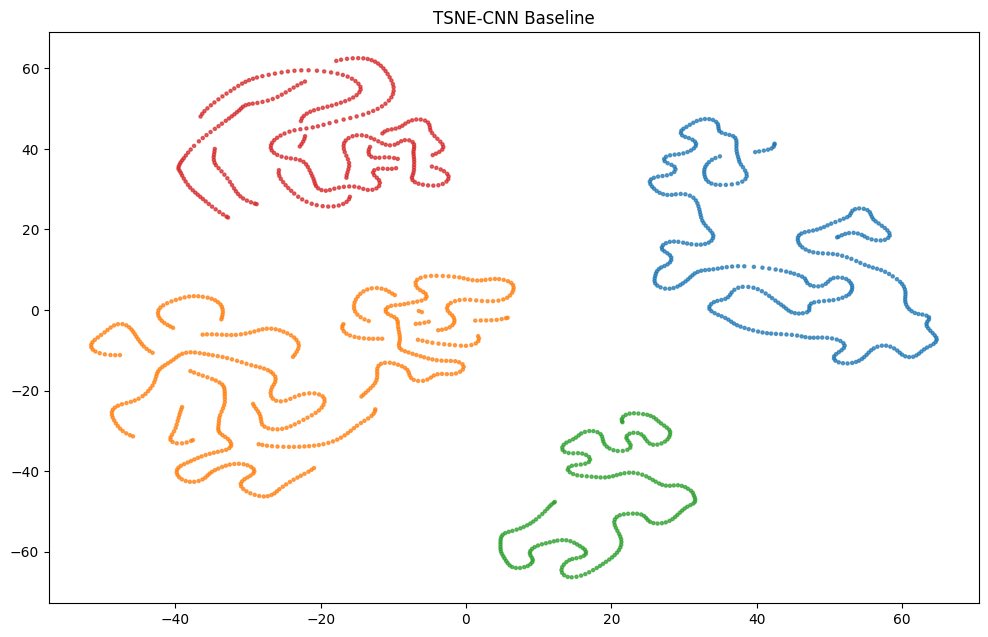

In [16]:
results_path = Path(f"./results/production/CNN-BIGBOSS/conv_neurons_16_128_pooling_2_2_dropout_0_kernel_7_class_neurons_32_class_dropout_0_lr_0.0001")
embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
embeddings = embeddings[0]
all_targets = all_targets[0]

fig, ax = plt.subplots(figsize=(12, 12/ 1.618))
plot_tsne_embeddings(ax, embeddings, all_targets, palette=palette, title="TSNE-CNN Baseline")
plt.show()

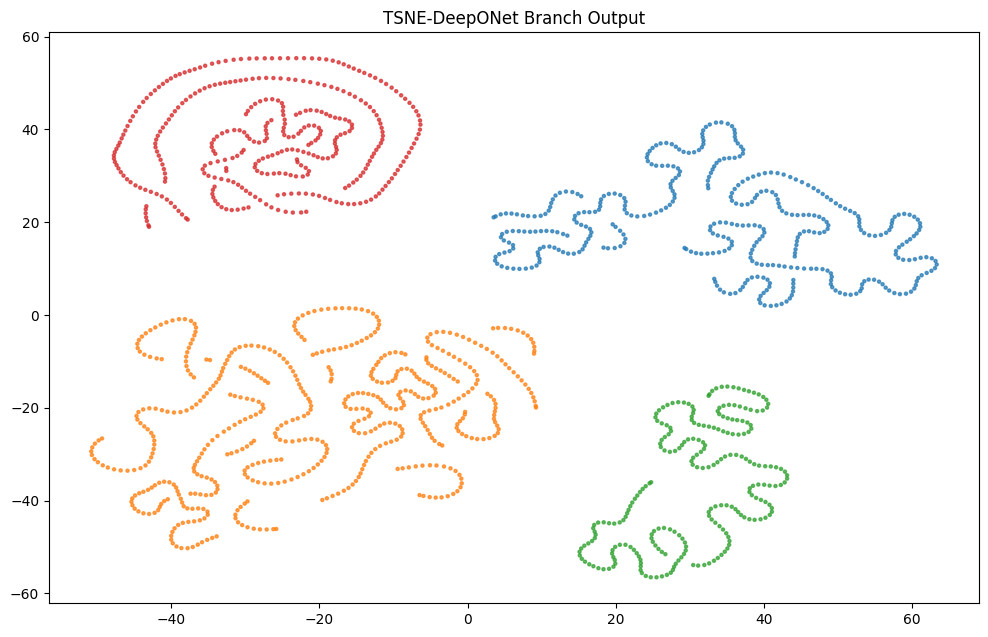

In [12]:
results_path = Path(f"./results/production/DeepONet-CNN-MLP/conv_neurons_16_128_pooling_2_2_dropout_0_kernel_7_class_neurons_32_class_dropout_0_lr_0.0001_hidden_64_32_dropout_0.2_embedding_128")
embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
embeddings = embeddings[0]
all_targets = all_targets[0]

fig, ax = plt.subplots(figsize=(12, 12/ 1.618))
plot_tsne_embeddings(ax, embeddings, all_targets, palette=palette, title="TSNE-DeepONet: Branch Output")
plt.show()

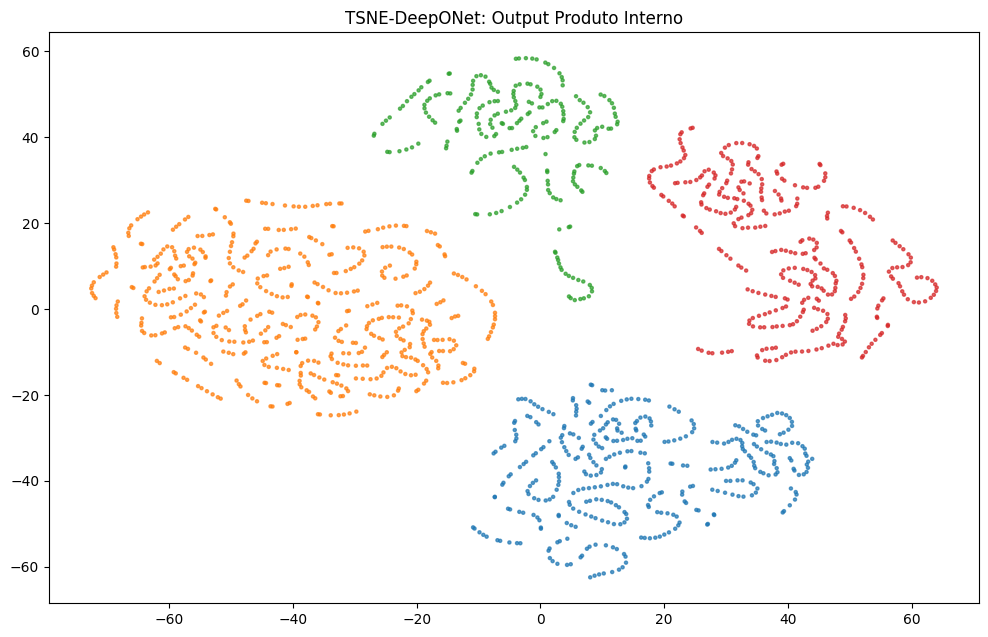

In [17]:
results_path = Path(f"./results/production/ConvDeepONet-v6/conv_neurons_16_128_pooling_2_2_dropout_0_kernel_7_class_neurons_32_class_dropout_0_lr_0.0001_hidden_64_32_dropout_0.2_embedding_128")
embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
embeddings = embeddings[0]
all_targets = all_targets[0]

fig, ax = plt.subplots(figsize=(12, 12/ 1.618))
plot_tsne_embeddings(ax, embeddings, all_targets, palette=palette, title="TSNE-DeepONet: Output Produto Interno")
plt.show()